
## Section 0 · Setup & Configuration

### 0.1 Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.3f}'.format)
pd.set_option('display.max_colwidth', 60)

### 0.2 File Paths 


In [ ]:
import os
from pathlib import Path

BASE_DIR   = Path(r'C:/Hackathon-GSK/Final_Submission/outputs/basetable')
CHARTS_DIR = Path(r'C:/Hackathon-GSK/Final_Submission/outputs/descriptive_analysis')
OUTPUTS_DIR = Path(r'C:/Hackathon-GSK/Final_Submission/outputs')

CHARTS_DIR.mkdir(parents=True, exist_ok=True)
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

### 0.3 SEROTYPE_CONFIG 

In [5]:
SEROTYPE_CONFIG = [
    ('IP1', 'ip1_basetable_v5.parquet', 'ST1'),
    ('IP3', 'ip3_basetable_v5.parquet', 'ST3'),
]

### 0.4 STAGE_CONFIG 

In [6]:
STAGE_CONFIG = [
    {'name': 'clarif', 'feature_prefixes': ['clarif_'],
     'target': 'clarif_007 Clarif - Yield total [%]', 'target_type': 'local',
     'exclude_output_cols': True, 'output_exclude_patterns': [
         'Ag content', 'Protein by Lowry', 'Ag total',
         'Prot total', 'Yield', 'Total volume', '% elimination']},
    {'name': 'uf', 'feature_prefixes': ['UF_'],
     'target': 'UF_008 UF - Yield [%]', 'target_type': 'local',
     'exclude_output_cols': False, 'output_exclude_patterns': []},
    {'name': 'pg', 'feature_prefixes': ['PG_', 'pg_', 'ev_pg'],
     'target': 'PG_009 PG - Yield [%]', 'target_type': 'local',
     'exclude_output_cols': False, 'output_exclude_patterns': []},
    {'name': 'deae', 'feature_prefixes': ['DEAE_', 'deae_', 'ev_deae'],
     'target': 'GY_011 PSV - Global Yield total [%]', 'target_type': 'global',
     'exclude_output_cols': False, 'output_exclude_patterns': []},
    {'name': 'psv_global', 'feature_prefixes': ['PSV_', 'GY_'],
     'target': 'GY_011 PSV - Global Yield total [%]', 'target_type': 'global',
     'exclude_output_cols': True, 'output_exclude_patterns': []},
]

### 0.5 Drop Patterns & Audit Column Helper

In [7]:
DROP_PATTERNS = [
    'Corrected Parameter', 'Double check', '3rd check', 'Remark', 'NF_','prep_'
]
ID_COLS = ['Batch', 'Reference Date']

def drop_audit_cols(df):
    to_drop = [c for c in df.columns
               if any(pat in c for pat in DROP_PATTERNS)]
    df.drop(columns=to_drop, inplace=True, errors='ignore')
    return to_drop


### 0.6 ALL_YIELD_COLS

In [8]:
ALL_YIELD_COLS = [
    'clarif_Clarif - Yield Ag [%]',
    'clarif_007 Clarif - Yield total [%]',
    'UF_008 UF - Yield [%]',
    'PG_009 PG - Yield [%]',
    'PSV_010 PSV - Yield [%]',
    'GY_PSV - Global Yield [%]',
    'GY_011 PSV - Global Yield total [%]',
]

---
## Section 1 · Load & Validate All 3 Serotypes

### 1.1 Load CSVs & Assert Targets Present

In [9]:
data = {}  # keyed by serotype label, e.g. 'IP1'

for label, fname, st_code in SEROTYPE_CONFIG:
    path = BASE_DIR / fname
    df = pd.read_parquet(path)
    data[label] = df

### 1.2 Drop Audit Columns & Preprocess Known Non-Numeric Fields

In [10]:
def hms_to_min(s):
    try:
        parts = str(s).split(':')
        return int(parts[0]) * 60 + int(parts[1]) + int(parts[2]) / 60
    except Exception:
        return np.nan

for label in data:
    df = data[label]
    dropped = drop_audit_cols(df)
    print(f'{label}: dropped {len(dropped)} audit columns → {df.shape[1]} remain')

    dur_col = 'DEAE_DEAE - Stock duration pool PG'
    if dur_col in df.columns:
        df[dur_col] = df[dur_col].apply(hms_to_min)
        print(f'  Converted {dur_col} to minutes')

IP1: dropped 117 audit columns → 747 remain
  Converted DEAE_DEAE - Stock duration pool PG to minutes
IP3: dropped 115 audit columns → 746 remain
  Converted DEAE_DEAE - Stock duration pool PG to minutes



## Section 2 · Descriptive Analysis (Univariate)

Structure: **outer loop = serotype** (IP1, IP2, IP3) · **inner loop = stage** (clarif, uf, pg, deae, psv_global)

For each combination: target distribution → SAP scatter → sensor scatter → PCA.

### 2.0 Helper — `get_candidate_features()`

In [11]:
def get_candidate_features(df, stage):
    prefixes = stage['feature_prefixes']
    cols = [c for c in df.columns if any(c.startswith(p) for p in prefixes)]
    cols = [c for c in cols if c not in ALL_YIELD_COLS]
    cols = [c for c in cols if not any(pat in c for pat in DROP_PATTERNS)]
    if stage.get('exclude_output_cols') and stage['name'] == 'clarif':
        out_pats = stage.get('output_exclude_patterns', [])
        cols = [c for c in cols if not any(p in c for p in out_pats)]
    if stage['name'] == 'psv_global':
        cols = [c for c in cols if not (c.startswith('GY_') and 'Yield' in c)]
    num_df = df[cols].apply(pd.to_numeric, errors='coerce')
    cols = [c for c in cols if num_df[c].notna().sum() >= 5]
    return cols
def _regline(ax, x, y):
    try:
        if x.std() > 0:
            m, b = scipy.stats.linregress(x, y)[:2]
            xl = np.linspace(x.min(), x.max(), 50)
            ax.plot(xl, m * xl + b, color='red', lw=1.2)
    except Exception: pass
print('get_candidate_features() and _regline() defined.')

get_candidate_features() and _regline() defined.


### 2.1 Target Yield Distributions — Helper

In [12]:
def plot_target_dist(df, stage, serotype_name):
    target = stage['target']
    vals = pd.to_numeric(df[target], errors='coerce').dropna()
    mu, sigma = vals.mean(), vals.std()
    lo, hi = mu - 3 * sigma, mu + 3 * sigma
    tnum = pd.to_numeric(df[target], errors='coerce')
    out_mask = (tnum < lo) | (tnum > hi)
    n_out = int(out_mask.sum())
    out_ids = df.loc[out_mask, 'Batch'].tolist() if 'Batch' in df.columns else []

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(vals, bins=15, alpha=0.6, density=True, color='steelblue', label='Histogram')
    vals.plot.kde(ax=ax, color='navy', lw=2, label='KDE')
    ax.axvline(lo, color='red', ls='--', lw=1.5, label=f'\u22123\u03c3 ({lo:.1f})')
    ax.axvline(hi, color='red', ls='--', lw=1.5, label=f'+3\u03c3 ({hi:.1f})')
    ax.set_xlabel(target, fontsize=8)
    ax.legend(fontsize=8)
    stats = (f'mean={mu:.2f}  median={vals.median():.2f}  std={sigma:.2f}\n'
             f'skew={vals.skew():.2f}  kurt={vals.kurtosis():.2f}  outliers={n_out}')
    ax.text(0.01, 0.97, stats, transform=ax.transAxes, va='top', fontsize=7,
            bbox=dict(fc='white', alpha=0.7, edgecolor='grey'))
    ax.set_title(f'{serotype_name} \u2014 {stage["name"]} yield distribution')
    fname = CHARTS_DIR / f'{serotype_name}_{stage["name"]}_yield_dist.png'
    fig.savefig(fname, bbox_inches='tight', dpi=100)
    plt.close(fig)
    print(f'  Saved {fname.name} | n_outliers={n_out} | batches: {out_ids}')

### 2.1 — Run Target Distribution Loop
Call `plot_target_dist()` for every serotype × stage combination

In [13]:
print('=== 2.1  Target yield distributions ===')
for label, fname, st_code in SEROTYPE_CONFIG:
    print(label + ':')
    df = data[label]
    for stage in STAGE_CONFIG:
        plot_target_dist(df, stage, label)

=== 2.1  Target yield distributions ===
IP1:
  Saved IP1_clarif_yield_dist.png | n_outliers=1 | batches: ['1_d5923f07351ee898541896415e6c9770129bb19f58ebd2743e79e8b0b81c8db6_']
  Saved IP1_uf_yield_dist.png | n_outliers=2 | batches: ['1_64accefdd12cc8006633c07609b0e52e6d8e25628cfe3c51041f0781b1526909_', '1_5dd58bd113a1a0321acf390c80bdc38d3bfb41a28791d0a87c77cdeed508891f_']
  Saved IP1_pg_yield_dist.png | n_outliers=0 | batches: []
  Saved IP1_deae_yield_dist.png | n_outliers=0 | batches: []
  Saved IP1_psv_global_yield_dist.png | n_outliers=0 | batches: []
IP3:
  Saved IP3_clarif_yield_dist.png | n_outliers=0 | batches: []
  Saved IP3_uf_yield_dist.png | n_outliers=2 | batches: ['3_36ab829f6301be386861f84469b6048a6cd958525b8aa16dcbf7b7008396b707_', '3_962bc31eff96dbd80afad200d97bc9938f5ae0615de6af6900a35a80c16f7816_']
  Saved IP3_pg_yield_dist.png | n_outliers=1 | batches: ['3_29b907965f671a0ce62b7f160b1602e2ebe8dc4aec87e6843e062aabe5a45ffe_']
  Saved IP3_deae_yield_dist.png | n_outlie

### 2.2 SAP Feature Scatter Plots — Helper
Define `plot_sap_scatter()` which draws one scatter + regression line per SAP candidate feature vs the stage target.

In [14]:
def plot_sap_scatter(df, stage, serotype_name, candidate_cols):
    SENSOR_PREFIXES = (
        'sensor_',
        'pg_sensor_', 'deae_sensor_', 'prep_sensor_',
        'pg_elution_', 'deae_elution_',
    )
    sap_cols = [c for c in candidate_cols
                if not any(c.startswith(p) for p in SENSOR_PREFIXES)]

    target = stage['target']
    if not sap_cols:
        print(f'  No SAP candidates for {serotype_name}/{stage["name"]}')
        return
    ncols = 4
    nrows = max(1, (len(sap_cols) + ncols - 1) // ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3.5 * nrows), squeeze=False)
    axes = axes.flatten()
    for i, feat in enumerate(sap_cols):
        ax = axes[i]
        valid = df[[feat, target]].apply(pd.to_numeric, errors='coerce').dropna()
        ax.scatter(valid[feat], valid[target], s=20, alpha=0.7, color='steelblue')
        if len(valid) >= 3:
            _regline(ax, valid[feat], valid[target])
        ax.set_title(feat.split('_', 1)[-1][:40], fontsize=7)
        ax.tick_params(labelsize=6)
    for j in range(len(sap_cols), len(axes)):
        axes[j].set_visible(False)
    fig.suptitle(f'{serotype_name} — {stage["name"]} SAP features vs yield', y=1.02)
    fig.tight_layout(rect=[0, 0, 1, 0.98])
    fname = CHARTS_DIR / f'{serotype_name}_{stage["name"]}_scatter_sap.png'
    fig.savefig(fname, bbox_inches='tight', dpi=80)
    plt.close(fig)
    print(f'  Saved {fname.name} ({len(sap_cols)} SAP features)')

### 2.2 — Run SAP Scatter Loop
Execute `plot_sap_scatter()` for all 15 serotype × stage combinations

In [15]:
print('=== 2.2  SAP feature scatter plots ===')
for label, fname, st_code in SEROTYPE_CONFIG:
    print(label + ':')
    df = data[label]
    for stage in STAGE_CONFIG:
        cands = get_candidate_features(df, stage)
        plot_sap_scatter(df, stage, label, cands)

=== 2.2  SAP feature scatter plots ===
IP1:
  Saved IP1_clarif_scatter_sap.png (37 SAP features)
  Saved IP1_uf_scatter_sap.png (12 SAP features)
  Saved IP1_pg_scatter_sap.png (244 SAP features)
  Saved IP1_deae_scatter_sap.png (243 SAP features)
  Saved IP1_psv_global_scatter_sap.png (12 SAP features)
IP3:
  Saved IP3_clarif_scatter_sap.png (37 SAP features)
  Saved IP3_uf_scatter_sap.png (12 SAP features)
  Saved IP3_pg_scatter_sap.png (244 SAP features)
  Saved IP3_deae_scatter_sap.png (242 SAP features)
  Saved IP3_psv_global_scatter_sap.png (12 SAP features)


### 2.3 Sensor Feature Scatter Plots — Helper
Define `plot_sensor_scatter()` — identical layout to SAP scatter but restricted to `sensor_*_mean` columns.

In [16]:
def plot_sensor_scatter(df, stage, serotype_name):
    target = stage['target']
    stage_name = stage['name']

    # Map each stage to the sensor prefix that belongs to it
    STAGE_SENSOR_PREFIX = {
        'pg'         : ['pg_sensor_', 'pg_elution_'],
        'deae'       : ['deae_sensor_', 'deae_elution_'],
        'psv_global' : ['pg_sensor_', 'pg_elution_',
                        'deae_sensor_', 'deae_elution_'],
    }

    # clarif and uf have no chromatography sensor data — skip them
    if stage_name not in STAGE_SENSOR_PREFIX:
        print(f'  Skipping sensor scatter for {stage_name} — no sensor stage mapping')
        return

    allowed_prefixes = STAGE_SENSOR_PREFIX[stage_name]

    # Keep only _mean columns belonging to the correct stage prefix
    sensor_cols = [
        c for c in df.columns
        if any(c.startswith(p) for p in allowed_prefixes)
        and c.endswith('_mean')
    ]

    # Drop columns where fewer than 50% of batches have real (non-imputed) data
    # Proxy: if std is near zero, almost all values are the imputed mean → skip
    num_check = df[sensor_cols].apply(pd.to_numeric, errors='coerce')
    sensor_cols = [
        c for c in sensor_cols
        if num_check[c].notna().sum() >= 5
        and num_check[c].std() > 0.01   # filters out near-constant imputed cols
    ]

    if not sensor_cols:
        print(f'  No valid sensor _mean features for {serotype_name}/{stage_name}')
        return

    ncols = 4
    nrows = max(1, (len(sensor_cols) + ncols - 1) // ncols)
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(16, 3.5 * nrows), squeeze=False)
    axes = axes.flatten()

    for i, feat in enumerate(sensor_cols):
        ax = axes[i]
        valid = df[[feat, target]].apply(pd.to_numeric, errors='coerce').dropna()
        ax.scatter(valid[feat], valid[target], s=20, alpha=0.7, color='seagreen')
        if len(valid) >= 3:
            _regline(ax, valid[feat], valid[target])
        ax.set_title(feat.replace('pg_sensor_', '')
                        .replace('deae_sensor_', '')
                        .replace('pg_elution_', 'ELUT_')
                        .replace('deae_elution_', 'ELUT_')[:40], fontsize=7)
        ax.tick_params(labelsize=6)

    for j in range(len(sensor_cols), len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(f'{serotype_name} — {stage_name} Sensor features vs yield '
                 f'({len(sensor_cols)} features)', y=1.02)
    fig.tight_layout(rect=[0, 0, 1, 0.98])
    fname = CHARTS_DIR / f'{serotype_name}_{stage_name}_scatter_sensor.png'
    fig.savefig(fname, bbox_inches='tight', dpi=80)
    plt.close(fig)
    print(f'  Saved {fname.name} ({len(sensor_cols)} sensor features)')

### 2.3 — Run Sensor Scatter Loop
Execute `plot_sensor_scatter()` for all 15 combinations

In [17]:
print('=== 2.3  Sensor feature scatter plots ===')
for label, fname, st_code in SEROTYPE_CONFIG:
    print(label + ':')
    df = data[label]
    for stage in STAGE_CONFIG:
        plot_sensor_scatter(df, stage, label)

=== 2.3  Sensor feature scatter plots ===
IP1:
  Skipping sensor scatter for clarif — no sensor stage mapping
  Skipping sensor scatter for uf — no sensor stage mapping
  Saved IP1_pg_scatter_sensor.png (17 sensor features)
  Saved IP1_deae_scatter_sensor.png (17 sensor features)
  Saved IP1_psv_global_scatter_sensor.png (34 sensor features)
IP3:
  Skipping sensor scatter for clarif — no sensor stage mapping
  Skipping sensor scatter for uf — no sensor stage mapping
  Saved IP3_pg_scatter_sensor.png (18 sensor features)
  Saved IP3_deae_scatter_sensor.png (17 sensor features)
  Saved IP3_psv_global_scatter_sensor.png (35 sensor features)


### 2.4 PCA — Structure & Outlier Visualisation — Helper
Define `plot_pca()` which applies StandardScaler → PCA(2 components) and colours batches by their yield.

In [18]:
def plot_pca(df, stage, serotype_name, candidate_cols):
    target = stage['target']
    feat_df = df[candidate_cols].apply(pd.to_numeric, errors='coerce')
    combined = pd.concat([feat_df, df[[target, 'Batch']]], axis=1).dropna(subset=[target])
    feat_clean = combined[candidate_cols].fillna(combined[candidate_cols].median())
    feat_clean = feat_clean.loc[:, feat_clean.std() > 0]
    if feat_clean.shape[1] < 2:
        print(f'  Skipping PCA — <2 valid features ({serotype_name}/{stage["name"]})')
        return
    X = StandardScaler().fit_transform(feat_clean)
    pca = PCA(n_components=2, random_state=42)
    pcs = pca.fit_transform(X)
    tvals = pd.to_numeric(combined[target], errors='coerce').values
    mu, sig = np.nanmean(tvals), np.nanstd(tvals)
    is_out = (tvals < mu - 3 * sig) | (tvals > mu + 3 * sig)
    fig, ax = plt.subplots(figsize=(8, 6))
    sc = ax.scatter(pcs[:, 0], pcs[:, 1], c=tvals, cmap='RdYlGn',
                    s=50, alpha=0.85, vmin=np.nanmin(tvals), vmax=np.nanmax(tvals))
    plt.colorbar(sc, ax=ax, label=stage['target'][:35])
    for idx in np.where(is_out)[0]:
        ax.annotate(str(combined['Batch'].iloc[idx]),
                    (pcs[idx, 0], pcs[idx, 1]), fontsize=7, color='darkred')
    v = pca.explained_variance_ratio_ * 100
    ax.set_xlabel(f'PC1 ({v[0]:.1f}% var)')
    ax.set_ylabel(f'PC2 ({v[1]:.1f}% var)')
    ax.set_title(f'{serotype_name} \u2014 {stage["name"]} PCA (colour = yield)')
    fname = CHARTS_DIR / f'{serotype_name}_{stage["name"]}_pca.png'
    fig.savefig(fname, bbox_inches='tight', dpi=100)
    plt.close(fig)
    print(f'  Saved {fname.name} | var={v[0]:.1f}%+{v[1]:.1f}%')

### 2.4 — Run PCA Loop
Execute `plot_pca()` for all 15 combinations.

In [19]:
print('=== 2.4  PCA — structure visualisation ===')
for label, fname, st_code in SEROTYPE_CONFIG:
    print(label + ':')
    df = data[label]
    for stage in STAGE_CONFIG:
        cands = get_candidate_features(df, stage)
        sap_cands = [c for c in cands if not c.startswith('sensor_')]
        plot_pca(df, stage, label, sap_cands)

=== 2.4  PCA — structure visualisation ===
IP1:
  Saved IP1_clarif_pca.png | var=17.8%+12.1%
  Saved IP1_uf_pca.png | var=33.3%+17.1%
  Saved IP1_pg_pca.png | var=14.2%+9.6%
  Saved IP1_deae_pca.png | var=17.4%+7.6%
  Saved IP1_psv_global_pca.png | var=47.0%+18.8%
IP3:
  Saved IP3_clarif_pca.png | var=23.1%+14.0%
  Saved IP3_uf_pca.png | var=28.7%+17.0%
  Saved IP3_pg_pca.png | var=22.7%+10.2%
  Saved IP3_deae_pca.png | var=15.5%+7.0%
  Saved IP3_psv_global_pca.png | var=46.2%+19.8%


---
## Section 3 · Summary Charts for Presentation
Three charts saved to `outputs/EDA/charts_v5/`:
- `antigen_cascade.png` — antigen recovery from Harvest to PSV
- `yield_comparison_IP1_IP3.png` — stage yield box plots, IP1 vs IP3
- `regression_feature_ranking.png` — top features by |r|, local yield targets

In [20]:
%matplotlib inline
import matplotlib.patches as mpatches

FS_V5 = Path(r"C:\Hackathon-GSK\outputs\feature_selection_v5")

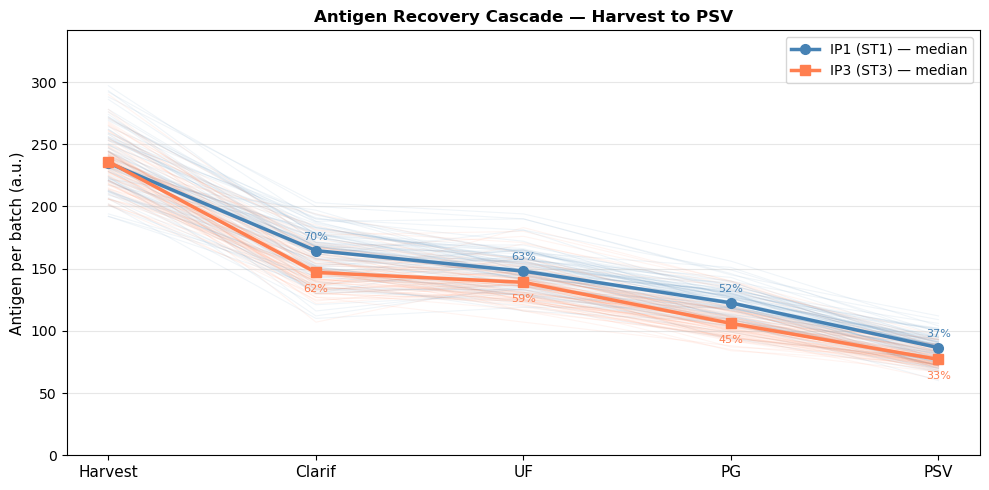

Saved antigen_cascade.png


In [21]:
# Chart 1 — Antigen Recovery Cascade (Harvest → PSV)
AG_COLS = {
    'Harvest': 'clarif_Harvest - Ag total',
    'Clarif':  'clarif_Clarif - Ag total',
    'UF':      'UF_UF - Ag total',
    'PG':      'PG_PG - Ag total',
    'PSV':     'PSV_PSV - Ag total',
}
x = np.arange(len(AG_COLS))

ip1 = data['IP1']
ip3 = data['IP3']

ip1_mat = np.array([pd.to_numeric(ip1[c], errors='coerce').values for c in AG_COLS.values()], dtype=float)
ip3_mat = np.array([pd.to_numeric(ip3[c], errors='coerce').values for c in AG_COLS.values()], dtype=float)
ip1_med = np.nanmedian(ip1_mat, axis=1)
ip3_med = np.nanmedian(ip3_mat, axis=1)

fig, ax = plt.subplots(figsize=(10, 5))
for i in range(ip1_mat.shape[1]):
    ax.plot(x, ip1_mat[:, i], color='steelblue', alpha=0.08, lw=0.8, zorder=1)
for i in range(ip3_mat.shape[1]):
    ax.plot(x, ip3_mat[:, i], color='coral', alpha=0.08, lw=0.8, zorder=1)
ax.plot(x, ip1_med, color='steelblue', lw=2.5, marker='o', markersize=7,
        label='IP1 (ST1) — median', zorder=3)
ax.plot(x, ip3_med, color='coral', lw=2.5, marker='s', markersize=7,
        label='IP3 (ST3) — median', zorder=3)
for xi, (m1, m3) in enumerate(zip(ip1_med, ip3_med)):
    if xi > 0:
        ax.annotate(f'{100 * m1 / ip1_med[0]:.0f}%', (xi, m1),
                    textcoords='offset points', xytext=(0, 8),
                    ha='center', fontsize=8, color='steelblue')
        ax.annotate(f'{100 * m3 / ip3_med[0]:.0f}%', (xi, m3),
                    textcoords='offset points', xytext=(0, -14),
                    ha='center', fontsize=8, color='coral')
ax.set_xticks(x)
ax.set_xticklabels(list(AG_COLS.keys()), fontsize=11)
ax.set_ylabel('Antigen per batch (a.u.)', fontsize=11)
ax.set_title('Antigen Recovery Cascade — Harvest to PSV', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, np.nanmax(ip1_mat) * 1.15)
fig.tight_layout()
fig.savefig(CHARTS_DIR / 'antigen_cascade.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved antigen_cascade.png')

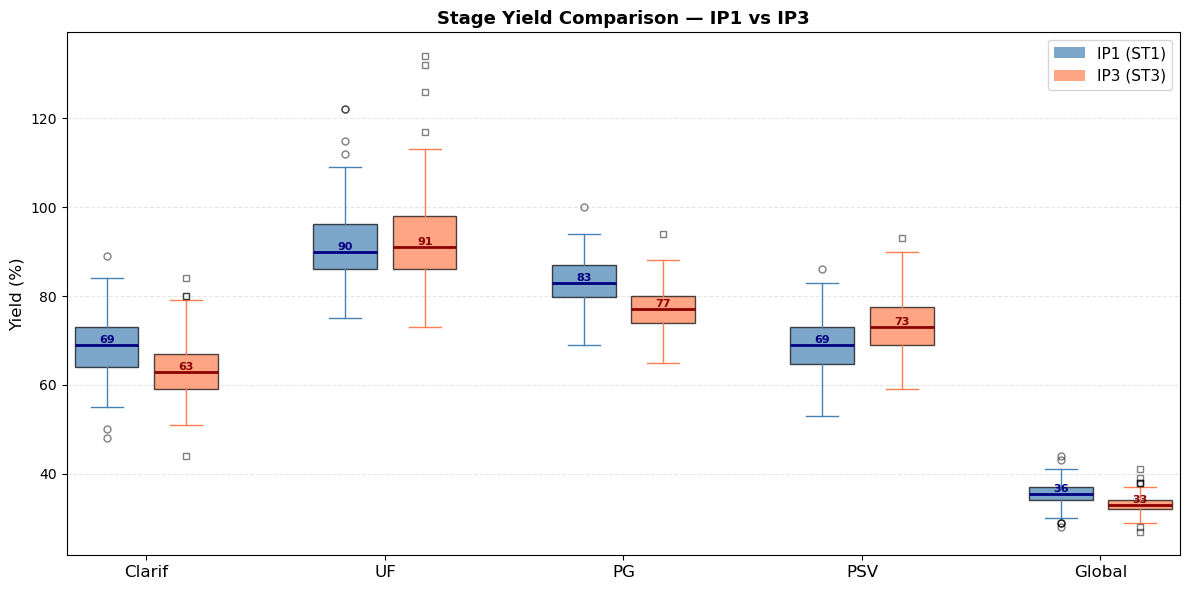

Saved yield_comparison_IP1_IP3.png


In [22]:
# Chart 2 — Stage Yield Comparison (IP1 vs IP3)
YIELD_COLS = {
    'Clarif': 'clarif_007 Clarif - Yield total [%]',
    'UF':     'UF_008 UF - Yield [%]',
    'PG':     'PG_009 PG - Yield [%]',
    'PSV':    'PSV_010 PSV - Yield [%]',
    'Global': 'GY_011 PSV - Global Yield total [%]',
}
stage_labels = list(YIELD_COLS.keys())
ip1_yield = [pd.to_numeric(ip1[c], errors='coerce').dropna().values for c in YIELD_COLS.values()]
ip3_yield = [pd.to_numeric(ip3[c], errors='coerce').dropna().values for c in YIELD_COLS.values()]

fig, ax = plt.subplots(figsize=(12, 6))
positions_ip1 = np.arange(len(stage_labels)) * 3
positions_ip3 = positions_ip1 + 1.0
ax.boxplot(ip1_yield, positions=positions_ip1, widths=0.8, patch_artist=True,
           boxprops=dict(facecolor='steelblue', alpha=0.7),
           medianprops=dict(color='navy', lw=2),
           whiskerprops=dict(color='steelblue'), capprops=dict(color='steelblue'),
           flierprops=dict(marker='o', color='steelblue', alpha=0.5, markersize=5))
ax.boxplot(ip3_yield, positions=positions_ip3, widths=0.8, patch_artist=True,
           boxprops=dict(facecolor='coral', alpha=0.7),
           medianprops=dict(color='darkred', lw=2),
           whiskerprops=dict(color='coral'), capprops=dict(color='coral'),
           flierprops=dict(marker='s', color='coral', alpha=0.5, markersize=5))
for xi, (m1, m3) in enumerate(zip([np.median(v) for v in ip1_yield],
                                   [np.median(v) for v in ip3_yield])):
    ax.text(positions_ip1[xi], m1, f'{m1:.0f}', ha='center', va='bottom',
            fontsize=8, color='navy', fontweight='bold')
    ax.text(positions_ip3[xi], m3, f'{m3:.0f}', ha='center', va='bottom',
            fontsize=8, color='darkred', fontweight='bold')
ax.set_xticks(positions_ip1 + 0.5)
ax.set_xticklabels(stage_labels, fontsize=12)
ax.set_ylabel('Yield (%)', fontsize=12)
ax.set_title('Stage Yield Comparison — IP1 vs IP3', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.legend(handles=[
    mpatches.Patch(facecolor='steelblue', alpha=0.7, label='IP1 (ST1)'),
    mpatches.Patch(facecolor='coral',     alpha=0.7, label='IP3 (ST3)'),
], fontsize=11)
fig.tight_layout()
fig.savefig(CHARTS_DIR / 'yield_comparison_IP1_IP3.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved yield_comparison_IP1_IP3.png')

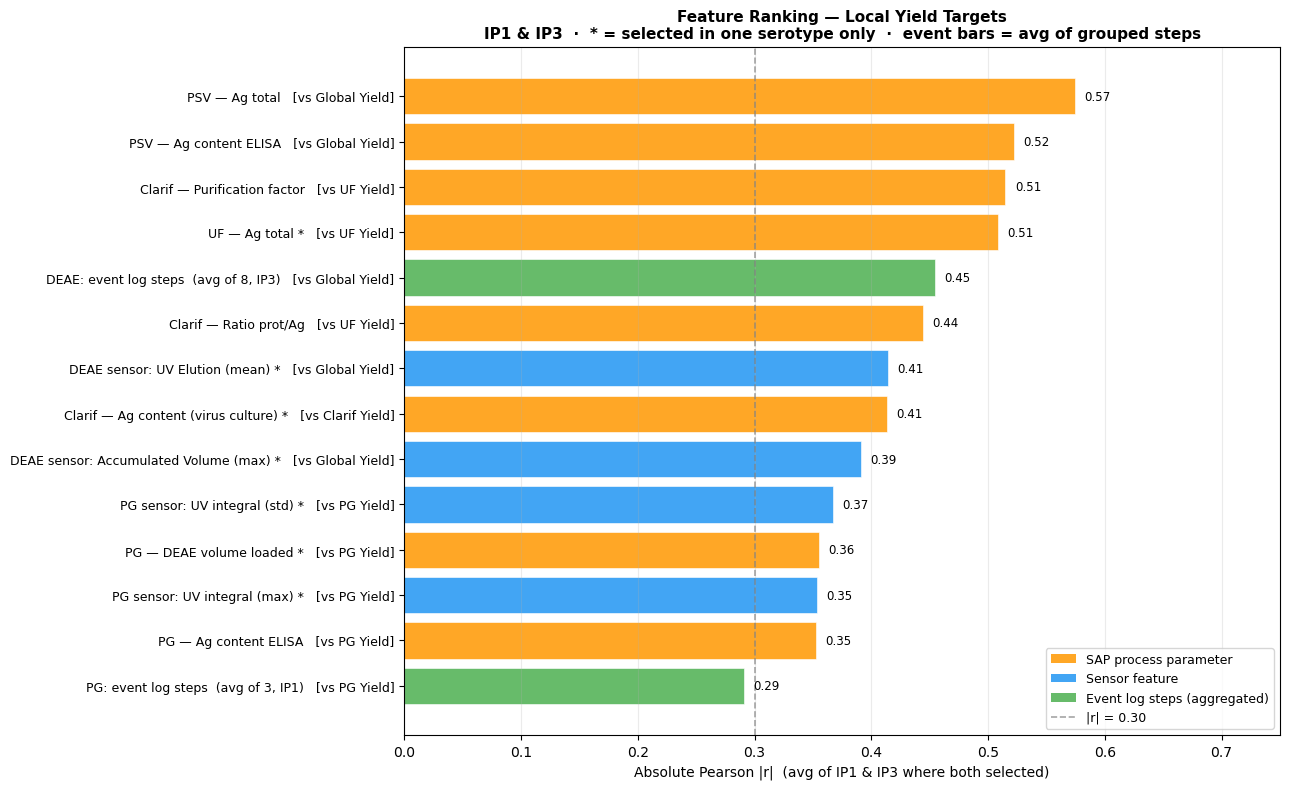

Saved regression_feature_ranking.png


In [25]:
# Chart 3 — Regression Feature Ranking
# 12 interpretable features + 2 aggregated event log bars
# Local yield targets per stage | * = single serotype | SAP=orange, sensor=blue, event=green

TARGET_LABEL = {
    'clarif':     'Clarif Yield',
    'uf':         'UF Yield',
    'pg':         'PG Yield',
    'deae':       'Global Yield',
    'psv_global': 'Global Yield',
}

reg = pd.read_csv(FS_V5 / 'regression_local_selected_features_v5.csv',encoding='latin-1')
reg = reg[reg['Serotype'].isin(['IP1', 'IP3'])].copy()

is_child2 = reg['Feature'].str.contains('child2', case=False)
child2_df  = reg[is_child2].copy()
interp_df  = reg[~is_child2].copy()

child2_agg = (child2_df.groupby(['Stage', 'Serotype'], as_index=False)
              .agg(Abs_r=('Abs_r', 'mean'), n=('Feature', 'count')))
child2_agg = child2_agg[child2_agg['Abs_r'] >= 0.27].copy()
child2_agg['target_label'] = child2_agg['Stage'].map(TARGET_LABEL)

event_rows = []
for _, row in child2_agg.iterrows():
    label = f"{row['Stage'].upper()}: event log steps  (avg of {int(row['n'])}, {row['Serotype']})"
    event_rows.append({'feat_label': label, 'Abs_r': row['Abs_r'],
                       'target_label': row['target_label'],
                       'n_st': -1, 'is_sensor': False, 'is_event': True})
event_frame = pd.DataFrame(event_rows)

n_st = interp_df.groupby('Feature')['Serotype'].nunique().rename('n_st')
avg  = (interp_df.groupby(['Feature', 'Stage'], as_index=False)['Abs_r'].mean()
        .merge(n_st, on='Feature')
        .sort_values('Abs_r', ascending=False)
        .head(12))
avg['target_label'] = avg['Stage'].map(TARGET_LABEL)

LABEL_MAP = {
    'PSV_PSV - Ag total':                          'PSV — Ag total',
    'PSV_005 PSV - Ag content Elisa [DU/ml]':      'PSV — Ag content ELISA',
    'UF_Clarif - Purification factor':             'Clarif — Purification factor',
    'UF_UF - Ag total':                            'UF — Ag total',
    'UF_Clarif - Ratio prot/Ag':                   'Clarif — Ratio prot/Ag',
    'deae_sensor_UV Elution_mean':                 'DEAE sensor: UV Elution (mean)',
    'clarif_001 Ag cont Elisa virus cult [DU/ml]': 'Clarif — Ag content (virus culture)',
    'deae_sensor_Accumulated Volume_max':          'DEAE sensor: Accumulated Volume (max)',
    'pg_sensor_RunCalc_UV_ForIntegral_v2_std':     'PG sensor: UV integral (std)',
    'PG_DEAE - Volume injected ml [ml]':           'PG — DEAE volume loaded',
    'pg_sensor_RunCalc_UV_ForIntegral_v2_max':     'PG sensor: UV integral (max)',
    'PG_004 PG - Ag content Elisa [DU/ml]':        'PG — Ag content ELISA',
    'PG_PG - Ag total':                            'PG — Ag total',
    'pg_sensor_RunCalc_UV_ForIntegral_v2_mean':    'PG sensor: UV integral (mean)',
    'PSV_PSV - Volume ml [ml]':                    'PSV — Volume',
}
SENSOR_PFX = ('pg_sensor_', 'deae_sensor_', 'pg_elution_', 'deae_elution_')

def feat_label(r):
    lbl = LABEL_MAP.get(r['Feature']) or (r['Feature'].split('_', 1)[1] if '_' in r['Feature'] else r['Feature'])[:52]
    if r['n_st'] == 1:
        lbl += ' *'
    return lbl

avg['feat_label'] = avg.apply(feat_label, axis=1)
avg['is_sensor']  = avg['Feature'].apply(lambda f: any(f.startswith(p) for p in SENSOR_PFX))
avg['is_event']   = False

combined = pd.concat([
    avg[['feat_label', 'Abs_r', 'target_label', 'n_st', 'is_sensor', 'is_event']],
    event_frame
], ignore_index=True).sort_values('Abs_r', ascending=False).reset_index(drop=True)

combined['y_label'] = combined.apply(
    lambda r: f"{r['feat_label']}   [vs {r['target_label']}]", axis=1)

def bar_color(r):
    if r['is_event']:  return '#4CAF50'
    if r['is_sensor']: return '#2196F3'
    return '#FF9800'
combined['color'] = combined.apply(bar_color, axis=1)

fig, ax = plt.subplots(figsize=(13, 8))
y_pos = np.arange(len(combined))
bars  = ax.barh(y_pos, combined['Abs_r'], color=combined['color'],
                alpha=0.85, edgecolor='white', linewidth=0.5)
ax.set_yticks(y_pos)
ax.set_yticklabels(combined['y_label'], fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Absolute Pearson |r|  (avg of IP1 & IP3 where both selected)', fontsize=10)
ax.set_title('Feature Ranking — Local Yield Targets\n'
             'IP1 & IP3  ·  * = selected in one serotype only  ·  event bars = avg of grouped steps',
             fontsize=11, fontweight='bold')
ax.set_xlim(0, 0.75)
ax.axvline(x=0.30, color='grey', linestyle='--', linewidth=1.2, alpha=0.7)
ax.grid(axis='x', alpha=0.25)
for bar, val in zip(bars, combined['Abs_r']):
    ax.text(bar.get_width() + 0.008, bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}', va='center', fontsize=8.5)
ax.legend(handles=[
    mpatches.Patch(facecolor='#FF9800', alpha=0.85, label='SAP process parameter'),
    mpatches.Patch(facecolor='#2196F3', alpha=0.85, label='Sensor feature'),
    mpatches.Patch(facecolor='#4CAF50', alpha=0.85, label='Event log steps (aggregated)'),
    plt.Line2D([0], [0], color='grey', linestyle='--', lw=1.2, alpha=0.7, label='|r| = 0.30'),
], fontsize=9, loc='lower right')
fig.tight_layout()
fig.savefig(CHARTS_DIR / 'regression_feature_ranking.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved regression_feature_ranking.png')